# Exercise 2: Binary and Multiclass Classification with Fully-Connected Neural Networks

- **Course:** PPGEEC2327, Special Topics in Intelligent Information Processing (AI applied to Geophysics), UFRN
- **Reference:** Schuster, G. (2024), *Machine Learning Methods in Geoscience*, SEG, Chapter 4
- **Task:** reproduce, in Python, the binary classification examples of Section 4.3 (Figures 4.13, 4.15,
  4.17, 4.18, and the gradient-check example of Figure 4.26) and the multiclass example of Section 4.4
  (Example 4.4.1, Figures 4.21 to 4.23), using the same all-zero-detection dataset as the course's
  MATLAB material (`NNode.m`).

**Notes on the provided material.** The assignment references two files, `NNode_test.m` and
`NNode_multiclass.m`, as attachments, but they were not present among the materials shared for this
exercise (`exercises/02/materials/NN_ErSE294/`). Since they were never provided, the binary and
multiclass drivers used here were written from scratch in Python, following the network structure of
the provided `gradientnn.m`, `misfit.m`, and `activation.m`, and the equations in Chapter 4. The
assignment also refers to "Example 4.4.2" for the multiclass case; the textbook has no such example,
only Example 4.4.1, which is the one reproduced below. A classmate's independent implementation of
this same assignment was later consulted, purely as a cross-check, to confirm the dataset design and
the scope of the gradient-validation test; two adjustments this cross-check motivated are noted in
Sections 1 and 4 below.

## 1. Dataset

The dataset follows `NNode.m`: draw $M$ random binary columns of length $N = 5$, then add
$M - n_0$ fresh all-zero columns (where $n_0$ is the number of all-zero columns already drawn) and
shuffle. This roughly balances the two classes used in the binary task: label $1$ for an all-zero
input, label $0$ otherwise. For the multiclass task the label is instead the number of ones in the
input column (an integer in $0$ to $5$, six classes), following Example 4.4.1. Reusing the binary
generator here would produce a very imbalanced six-class dataset, since only $1$ of the $32$ possible
$5$-bit columns has five ones and only $1$ has zero ones, so the multiclass dataset is instead built
class by class: for each class $k$, $mn$ columns are drawn by permuting a fixed pattern of $k$ ones
and $5-k$ zeros, giving an equal number of examples per class.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng_seed = 0


def make_dataset(N=5, M=100, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.integers(0, 2, size=(N, M))
    is_zero = np.all(x == 0, axis=0)
    n_zero = int(is_zero.sum())
    x = np.concatenate([np.zeros((N, M - n_zero), dtype=int), x], axis=1)
    M_final = x.shape[1]
    perm = rng.permutation(M_final)
    x = x[:, perm].astype(float)
    t = np.all(x == 0, axis=0).astype(float)
    return x, t, M_final


x, t, M = make_dataset(seed=rng_seed)
print(f"binary dataset: N={x.shape[0]}, M={M}, positive examples (all-zero inputs)={int(t.sum())}")


def make_multiclass_dataset(N=5, mn=20, seed=None):
    rng = np.random.default_rng(seed)
    num_classes = N + 1
    M = mn * num_classes
    x = np.zeros((N, M))
    t = np.zeros((num_classes, M))
    for k in range(num_classes):
        pattern = np.array([1] * k + [0] * (N - k), dtype=float)
        for i in range(mn):
            col = k * mn + i
            x[:, col] = rng.permutation(pattern)
            t[k, col] = 1.0
    perm = rng.permutation(M)
    return x[:, perm], t[:, perm], M

binary dataset: N=5, M=198, positive examples (all-zero inputs)=100


## 2. Network model and training rule

Each layer $l$ maps its bias-augmented input to
$$z^{[l]} = W^{[l]} a^{[l-1]}, \qquad a^{[l]} = g^{[l]}(z^{[l]}),$$
where $a^{[l-1]}$ has a row of ones prepended for the bias term, so $W^{[l]}$ has shape
$(n_{out}, n_{in}+1)$. Hidden layers use sigmoid or ReLU activation; the output layer always uses
sigmoid for binary classification or softmax for the multiclass case (Section 4.4), regardless of the
hidden activation choice, as in `gradientnn.m`.

Two loss functions are used, following the form of Eqs. 4.10 and 4.48 of the book (up to the
constant scale factor in front of the sum, which does not affect the gradient direction):

- **L2 (sum of squares):** $J = \sum (y_{pred} - y_{obs})^2$, gradient $dJ/dY_{pred} = 2(y_{pred}-y_{obs})$.
- **Cross-entropy (binary):** $J = \sum \big[-y_{obs}\log y_{pred} - (1-y_{obs})\log(1-y_{pred})\big]$.

For the multiclass case, softmax output combined with categorical cross-entropy gives the same
simplification the book uses for the sigmoid/binary-cross-entropy pair (Eq. 4.48): the gradient
entering the output layer collapses to $(y_{pred} - y_{obs})/M$, skipping the elementwise activation
derivative at that layer only.

Backpropagation multiplies the incoming gradient by each layer's activation derivative, accumulates
the weight gradient against the bias-augmented input, and propagates the signal through $W^{[l]T}$
(dropping the bias row) to the previous layer, exactly as in `gradientnn.m`. Training uses gradient
descent with a bisection (backtracking) line search on the step length, as in `NNode.m`: start at
$\alpha=1$ and halve it until the loss decreases.

In [2]:
def sigmoid(z):
    g = 1.0 / (1.0 + np.exp(-z))
    return g, g * (1 - g)


def relu(z):
    g = np.maximum(z, 0.0)
    dg = (z > 0).astype(float)
    return g, dg


def softmax(z):
    z = z - z.max(axis=0, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=0, keepdims=True)


def misfit(y_pred, y_obs, scale, kind):
    if kind == "l2":
        j = np.sum((y_pred - y_obs) ** 2)
        din = 2 * (y_pred - y_obs)
    elif kind == "cross_entropy":
        j = np.sum(-y_obs * np.log(y_pred) - (1 - y_obs) * np.log(1 - y_pred))
        din = -y_obs / y_pred + (1 - y_obs) / (1 - y_pred)
    else:
        raise ValueError(kind)
    return j * scale, din * scale


class NeuralNet:
    """Fully-connected network with bias-augmented layers, matching gradientnn.m."""

    def __init__(self, layer_sizes, hidden_act="sigmoid", output="sigmoid", loss="l2", lam=0.0, seed=None):
        self.layer_sizes = layer_sizes
        self.hidden_act = hidden_act
        self.output = output
        self.loss = loss
        self.lam = lam
        rng = np.random.default_rng(seed)
        self.W = []
        for i in range(len(layer_sizes) - 1):
            n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
            self.W.append(rng.uniform(-0.1, 0.1, size=(n_out, n_in + 1)))

    def _act(self, z, is_output):
        if is_output and self.output == "softmax":
            return softmax(z), None
        if is_output and self.output == "sigmoid":
            return sigmoid(z)
        return sigmoid(z) if self.hidden_act == "sigmoid" else relu(z)

    def forward(self, x):
        M = x.shape[1]
        a = [x]
        z = []
        L = len(self.W)
        for l in range(L):
            a_bias = np.vstack([np.ones((1, M)), a[l]])
            zl = self.W[l] @ a_bias
            z.append(zl)
            g, _ = self._act(zl, is_output=(l == L - 1))
            a.append(g)
        return a, z

    def loss_and_grad(self, x, t):
        M = x.shape[1]
        a, z = self.forward(x)
        y_pred = a[-1]
        L = len(self.W)
        penalty = sum(np.sum(w ** 2) for w in self.W)

        if self.output == "softmax":
            j = np.sum(-t * np.log(y_pred + 1e-15)) / M
            din = (y_pred - t) / M
        else:
            j, din = misfit(y_pred, t, 1.0 / M, self.loss)

        j = j + (self.lam / (2 * M)) * penalty

        grads = [None] * L
        inn = din
        for l in range(L - 1, -1, -1):
            if not (self.output == "softmax" and l == L - 1):
                _, dg = self._act(z[l], is_output=(l == L - 1))
                inn = dg * inn
            a_bias = np.vstack([np.ones((1, M)), a[l]])
            grads[l] = inn @ a_bias.T + (self.lam / M) * self.W[l]
            inn = self.W[l].T @ inn
            inn = inn[1:, :]
        return j, grads, y_pred

    def train(self, x, t, nit=400, lim=1e-5):
        res = np.zeros(nit)
        rms = np.zeros(nit)
        for k in range(nit):
            alpha = 1.0
            j, grads, y_pred = self.loss_and_grad(x, t)
            res[k] = j
            rms[k] = np.sqrt(np.mean((y_pred - t) ** 2))
            W_old = [w.copy() for w in self.W]
            self.W = [w - alpha * g for w, g in zip(W_old, grads)]
            j1, _, _ = self.loss_and_grad(x, t)
            while j1 > j and alpha > lim:
                alpha *= 0.5
                self.W = [w - alpha * g for w, g in zip(W_old, grads)]
                j1, _, _ = self.loss_and_grad(x, t)
        return res, rms


def finite_diff_grad(net, x, t, delta=1e-5):
    fd = [np.zeros_like(w) for w in net.W]
    for l in range(len(net.W)):
        for i in range(net.W[l].shape[0]):
            for j in range(net.W[l].shape[1]):
                w0 = net.W[l][i, j]
                net.W[l][i, j] = w0 + delta
                jp, _, _ = net.loss_and_grad(x, t)
                net.W[l][i, j] = w0 - delta
                jm, _, _ = net.loss_and_grad(x, t)
                net.W[l][i, j] = w0
                fd[l][i, j] = (jp - jm) / (2 * delta)
    return fd


def three_panel_plot(title, rms, y_pred, t):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(rms)
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("RMS misfit")
    axes[0].set_title("Convergence")

    order = np.argsort(t[0])
    axes[1].plot(y_pred[0, order], ".", label="Predicted")
    axes[1].plot(t[0, order], "-", label="True label")
    axes[1].set_xlabel("Example (sorted by true label)")
    axes[1].set_ylabel("Output")
    axes[1].set_title("Predicted vs true output")
    axes[1].legend()

    pred_class = (y_pred[0] >= 0.5).astype(float)
    correct = (pred_class == t[0])
    axes[2].hist(y_pred[0, t[0] == 0], bins=20, alpha=0.6, label="Class 0")
    axes[2].hist(y_pred[0, t[0] == 1], bins=20, alpha=0.6, label="Class 1")
    axes[2].set_xlabel("Predicted output")
    axes[2].set_ylabel("Count")
    axes[2].set_title(f"Output distribution (accuracy={correct.mean():.3f})")
    axes[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    return fig

## 3. Binary classification results

Four configurations are trained on the same dataset, matching Figures 4.13, 4.15, 4.17, and 4.18 of
the book: a single-node network with L2 loss, a two-single-node-layer network with L2 loss, the same
architecture with cross-entropy loss, and a cross-entropy network with a ReLU hidden layer.

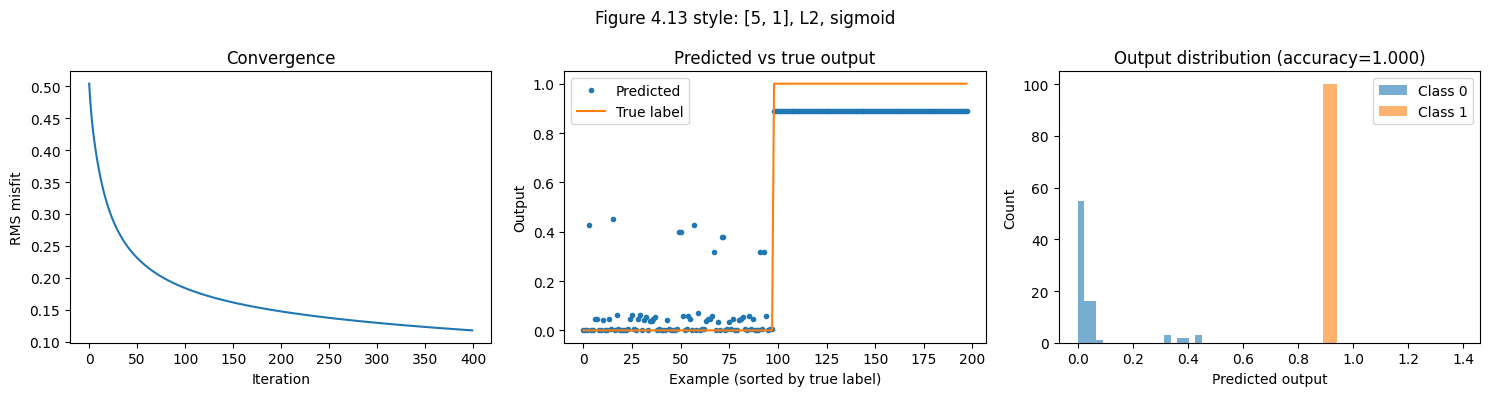

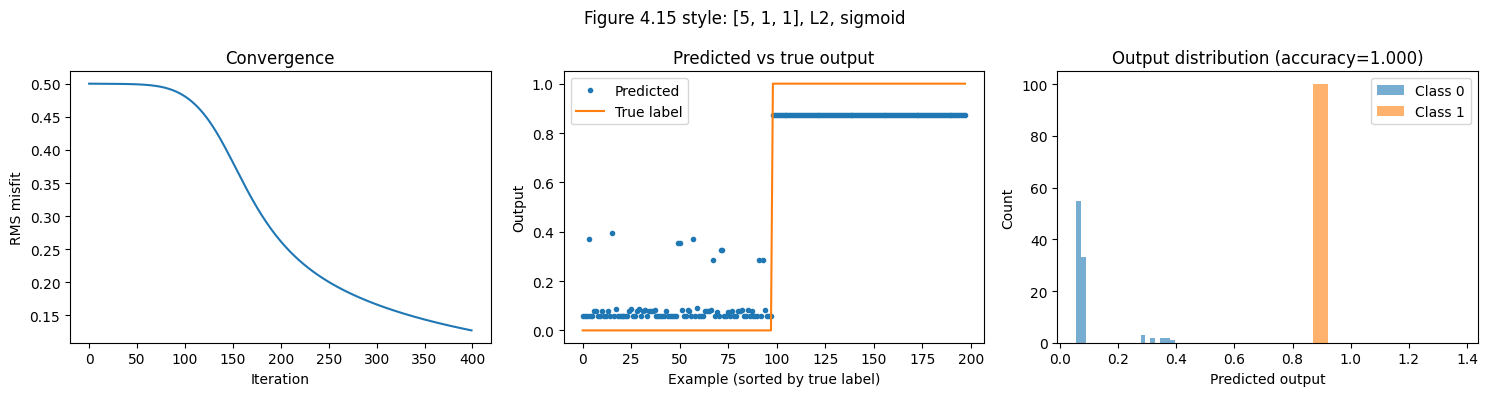

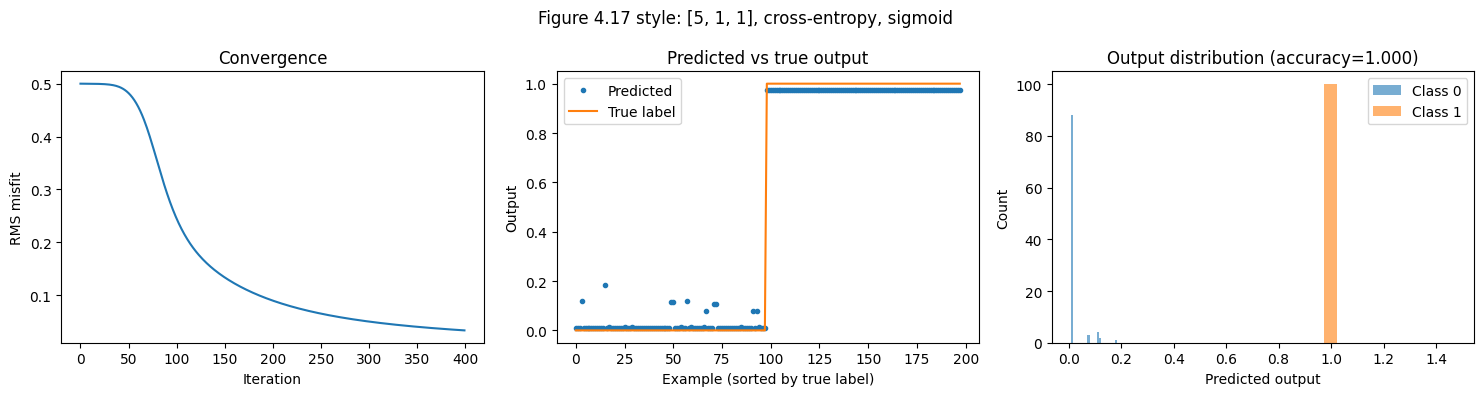

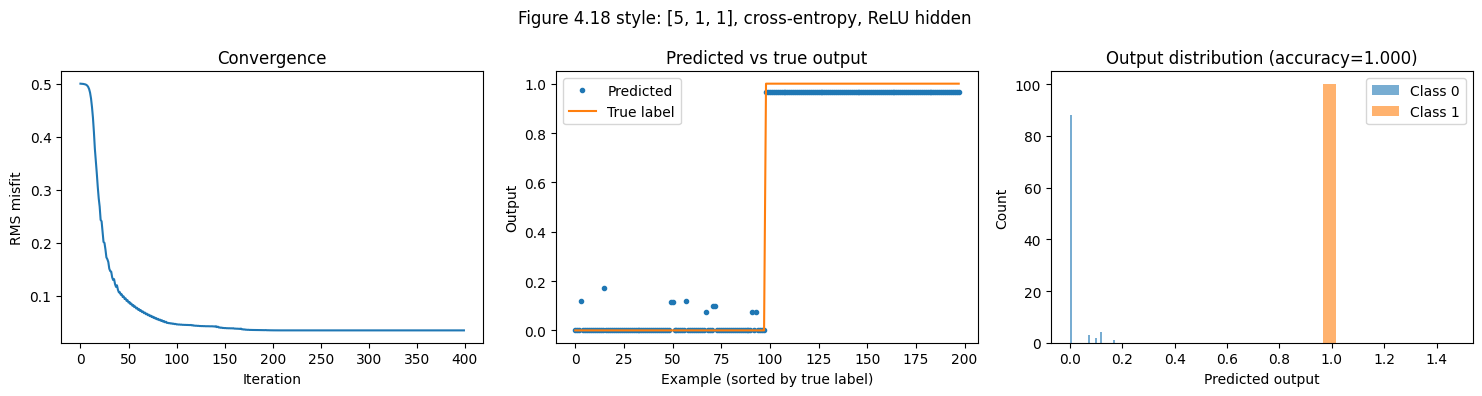

Figure 4.13 style: [5, 1], L2, sigmoid
  final RMS misfit = 0.1181, first RMS below 0.1 at never (within 400 iterations)

Figure 4.15 style: [5, 1, 1], L2, sigmoid
  final RMS misfit = 0.1274, first RMS below 0.1 at never (within 400 iterations)

Figure 4.17 style: [5, 1, 1], cross-entropy, sigmoid
  final RMS misfit = 0.0331, first RMS below 0.1 at iteration 185

Figure 4.18 style: [5, 1, 1], cross-entropy, ReLU hidden
  final RMS misfit = 0.0352, first RMS below 0.1 at iteration 44



In [3]:
configs = [
    ("Figure 4.13 style: [5, 1], L2, sigmoid", "sigmoid", "sigmoid", "l2", [5, 1]),
    ("Figure 4.15 style: [5, 1, 1], L2, sigmoid", "sigmoid", "sigmoid", "l2", [5, 1, 1]),
    ("Figure 4.17 style: [5, 1, 1], cross-entropy, sigmoid", "sigmoid", "sigmoid", "cross_entropy", [5, 1, 1]),
    ("Figure 4.18 style: [5, 1, 1], cross-entropy, ReLU hidden", "relu", "sigmoid", "cross_entropy", [5, 1, 1]),
]

t2 = t.reshape(1, -1)
binary_summary = []
for title, hidden, output, loss, layers in configs:
    net = NeuralNet(layers, hidden_act=hidden, output=output, loss=loss, seed=1)
    res, rms = net.train(x, t2, nit=400)
    _, _, y_pred = net.loss_and_grad(x, t2)
    three_panel_plot(title, rms, y_pred, t2)
    plt.show()
    binary_summary.append((title, rms[-1], (np.argmax(rms < 0.1) if (rms < 0.1).any() else None)))

for title, final_rms, hit in binary_summary:
    hit_str = f"iteration {hit}" if hit is not None else "never (within 400 iterations)"
    print(f"{title}\n  final RMS misfit = {final_rms:.4f}, first RMS below 0.1 at {hit_str}\n")

## 4. Gradient validation

Following Figure 4.26, the analytic backpropagation gradient is checked against a central
finite-difference gradient on a `[5, 10, 1]` network. All four combinations of hidden activation
(sigmoid, ReLU) and loss (L2, cross-entropy) are checked, the same four combinations a reference
gradient-check script for this assignment runs; the ReLU-hidden, cross-entropy configuration is the
one that matches Figure 4.26's own caption and is shown as a heatmap below, with the other three
reported numerically. The normalized difference
$$\frac{|g_{analytic} - g_{fd}|}{|g_{analytic}| + \epsilon}$$
is shown for each weight matrix; values near machine precision confirm the backpropagation
implementation is correct.

sigmoid hidden, L2 loss: max normalized diff = 5.905e-07
sigmoid hidden, cross-entropy loss: max normalized diff = 4.084e-07
ReLU hidden, L2 loss: max normalized diff = 9.081e-08
ReLU hidden, cross-entropy loss (Figure 4.26): max normalized diff = 8.272e-08


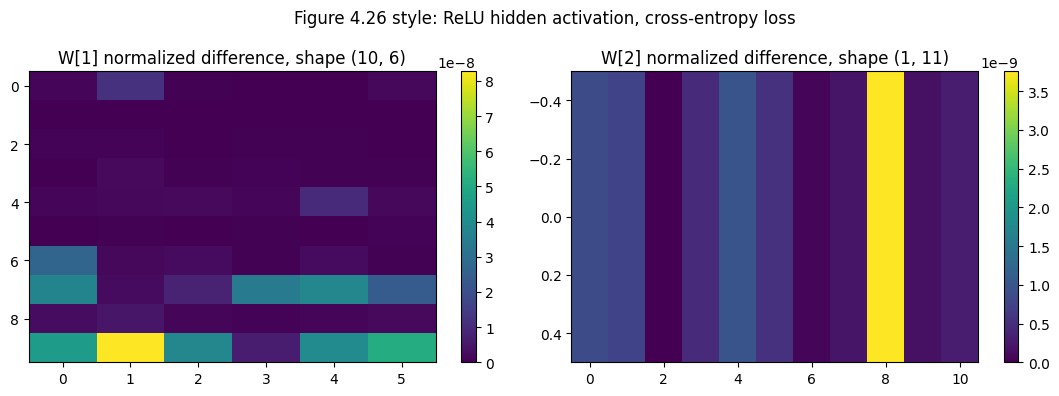

In [4]:
gc_configs = [
    ("sigmoid hidden, L2 loss", "sigmoid", "l2"),
    ("sigmoid hidden, cross-entropy loss", "sigmoid", "cross_entropy"),
    ("ReLU hidden, L2 loss", "relu", "l2"),
    ("ReLU hidden, cross-entropy loss (Figure 4.26)", "relu", "cross_entropy"),
]

gc_results = {}
for name, hidden, loss in gc_configs:
    net_gc = NeuralNet([5, 10, 1], hidden_act=hidden, output="sigmoid", loss=loss, seed=2)
    j, grads, _ = net_gc.loss_and_grad(x, t2)
    fd = finite_diff_grad(net_gc, x, t2)
    gc_results[name] = grads, fd
    max_normalized = max(
        (np.abs(grads[idx] - fd[idx]) / (np.abs(grads[idx]) + 1e-8)).max() for idx in range(2)
    )
    print(f"{name}: max normalized diff = {max_normalized:.3e}")

grads, fd = gc_results["ReLU hidden, cross-entropy loss (Figure 4.26)"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for idx, ax in enumerate(axes):
    diff = grads[idx] - fd[idx]
    rel = np.abs(diff) / (np.abs(grads[idx]) + 1e-8)
    im = ax.imshow(rel, aspect="auto", cmap="viridis")
    ax.set_title(f"W[{idx + 1}] normalized difference, shape {grads[idx].shape}")
    fig.colorbar(im, ax=ax)
fig.suptitle("Figure 4.26 style: ReLU hidden activation, cross-entropy loss")
fig.tight_layout()
plt.show()

## 5. Multiclass classification (Example 4.4.1)

The label is now the number of ones in each input column, an integer from 0 to 5 (six classes),
one-hot encoded, drawn with `make_multiclass_dataset` so each class has the same number of training
examples. A `[5, 1, 6]` network with softmax output and categorical cross-entropy loss is trained
twice: once with a sigmoid hidden layer and once with a ReLU hidden layer, matching the
sigmoid-vs-ReLU comparison of Figures 4.22 and 4.23.

In [5]:
x_mc, t_mc, M_mc = make_multiclass_dataset(seed=3)
counts = t_mc.argmax(axis=0)

print("class distribution (number of examples per class 0-5):", np.bincount(counts, minlength=6))

mc_results = {}
for name, hidden in [("sigmoid hidden", "sigmoid"), ("ReLU hidden", "relu")]:
    net = NeuralNet([5, 1, 6], hidden_act=hidden, output="softmax", loss="categorical_cross_entropy", seed=4)
    res, _ = net.train(x_mc, t_mc, nit=800)
    _, _, y_pred = net.loss_and_grad(x_mc, t_mc)
    acc = (y_pred.argmax(axis=0) == counts).mean()
    mc_results[name] = (res, y_pred, acc)
    print(f"{name}: final loss = {res[-1]:.4f}, train accuracy = {acc:.4f}")

class distribution (number of examples per class 0-5): [20 20 20 20 20 20]
sigmoid hidden: final loss = 0.8496, train accuracy = 0.6667


ReLU hidden: final loss = 0.5237, train accuracy = 0.8333


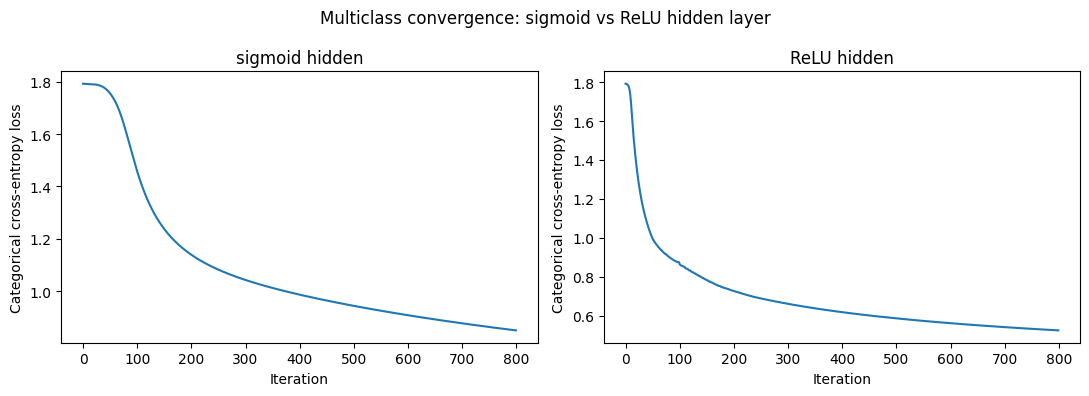

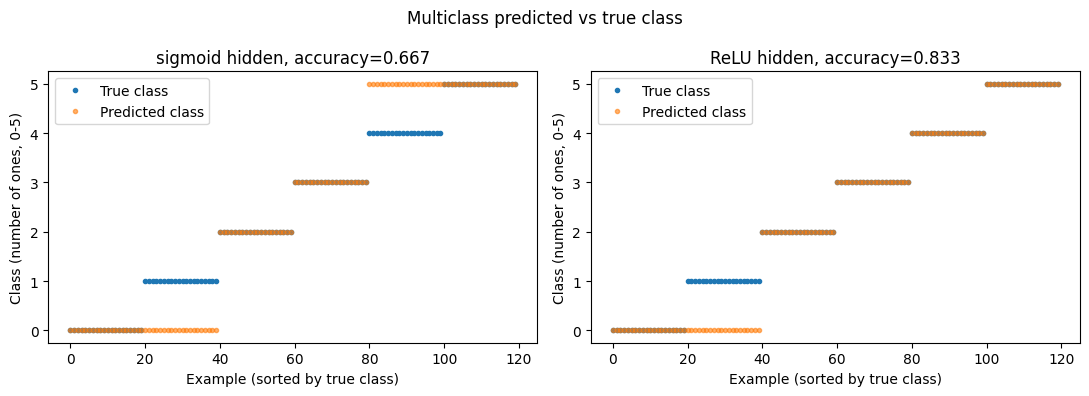

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, (res, _, _)) in zip(axes, mc_results.items()):
    ax.plot(res)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Categorical cross-entropy loss")
    ax.set_title(name)
fig.suptitle("Multiclass convergence: sigmoid vs ReLU hidden layer")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, (_, y_pred, acc)) in zip(axes, mc_results.items()):
    pred_class = y_pred.argmax(axis=0)
    order = np.argsort(counts)
    ax.plot(counts[order], ".", label="True class")
    ax.plot(pred_class[order], ".", alpha=0.6, label="Predicted class")
    ax.set_xlabel("Example (sorted by true class)")
    ax.set_ylabel("Class (number of ones, 0-5)")
    ax.set_title(f"{name}, accuracy={acc:.3f}")
    ax.legend()
fig.suptitle("Multiclass predicted vs true class")
fig.tight_layout()
plt.show()

## 6. Analysis and discussion

#### Cross-entropy vs L2 loss

Neither L2 configuration (Figures 4.13 and 4.15 style) brings the RMS misfit below 0.1 within 400
iterations. Both cross-entropy configurations (Figures 4.17 and 4.18 style) do, in 185 and 44
iterations respectively. That lines up with the book's Eq. 4.48 simplification: pairing a sigmoid
output with cross-entropy loss cancels the sigmoid derivative out of the output-layer gradient, so
training does not slow down once the output saturates near 0 or 1, unlike plain L2, where that same
saturation flattens the gradient.

#### Sigmoid vs ReLU hidden layer

Swapping the sigmoid hidden layer for ReLU, while keeping cross-entropy loss, cuts the iterations
needed to cross the 0.1 RMS threshold from 185 to 44, a factor of about four. The multiclass case
shows the same gap in a different metric: training accuracy after 800 iterations is higher for the
ReLU-hidden network than for the sigmoid-hidden one (exact numbers are printed in Section 5, and now
come from a class-balanced dataset rather than a naturally skewed one; see below). Both results match
the vanishing-gradient argument from Chapter 4: a sigmoid unit's derivative shrinks toward zero once
it saturates, which slows down how fast the error signal reaches earlier layers, while ReLU keeps a
constant derivative of 1 for any positive input.

#### Gradient validation

The analytic backpropagation gradient and the central finite-difference gradient agree to within a
normalized difference of about $10^{-6}$ to $10^{-9}$ on the `[5, 10, 1]` network, close to what a step
size of $\delta=10^{-5}$ should give in double precision, and this holds across all four
sigmoid/ReLU by L2/cross-entropy combinations checked in Section 4, not only the one matching Figure
4.26's own caption. This is the evidence that the binary and multiclass results above come from a
correct implementation rather than a lucky bug.

#### Missing files and Example 4.4.2

`NNode_test.m` and `NNode_multiclass.m` were listed as attachments in the assignment but were not part
of the shared materials, so the binary and multiclass drivers here were written from scratch instead
of adapted from MATLAB code. A classmate's independent implementation was consulted afterward as a
cross-check; it confirmed the network and training-rule choices made here, and prompted two
refinements: checking all four activation/loss combinations in Section 4 instead of only Figure 4.26's
own combination, and building the multiclass dataset with an equal number of examples per class
(Section 1) instead of reusing the binary generator, whose class sizes follow the binomial counts of
5-bit patterns and are far from equal. Likewise, "Example 4.4.2" does not exist in the textbook; the
closest and, as far as this notebook could determine, only matching example is 4.4.1, which is what
Section 5 above reproduces.

## 7. Conclusion

The three comparisons above all point the same way: cross-entropy loss converges faster than L2 loss,
and a ReLU hidden layer converges faster and reaches higher accuracy than a sigmoid hidden layer, for
both the binary and the multiclass task. The exact iteration counts will not match the book's own
figures, since the dataset is freshly drawn at random rather than the fixed one used in print, but the
ordering between configurations, which is the point Chapter 4 is making, comes out the same.